# Decision Tree Regressor with Performance Metrics, Split Criterion, and Hyperparameters chosen by user

In [9]:
# Decision Tree Regressor example on the California housing dataset (from sklearn)
# Possible split criteria for regression (examples):
# - "squared_error" (MSE / variance reduction)         -- sklearn >=1.0 name for MSE
# - "friedman_mse" (Friedman improvement score)
# - "absolute_error" (MAE)                             -- L1-based, more robust to outliers
# - "poisson" (Poisson deviance)                       -- for count-like targets
#
# Possible performance metrics (examples):
# - Mean Squared Error (MSE)         -> "mse"
# - Root Mean Squared Error (RMSE)   -> "rmse"
# - Mean Absolute Error (MAE)        -> "mae"
# - R^2 (coefficient of determination) -> "r2"
# - Explained variance                -> "explained_variance"
#
# This script lets the user choose:
#  - split criterion used inside the DecisionTreeRegressor (criterion_choice)
#  - performance metric used to evaluate predictions (metric_choice)
#  - other tree hyperparameters in the user_params dict (max_depth, min_samples_leaf, etc.)
#
# Two experiments are run:
#  1) Fit on entire dataset (no train/test split) and evaluate on the same data.
#     With an unconstrained tree (max_depth=None, min_samples_leaf=1), training-set MSE will typically be close to 0.
#  2) Fit with a train/test split and evaluate on the held-out test set.
#
# For each experiment we print the chosen metric and the feature importances.
# To change choices, edit the variables under "User-selectable choices" below.

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.model_selection import train_test_split

# --- User-selectable choices ---
# Choose split criterion (for the tree). Examples:
# "squared_error", "friedman_mse", "absolute_error", "poisson"
criterion_choice = "squared_error"  # user can change this

# Choose performance metric for evaluation: "mse", "rmse", "mae", "r2", "explained_variance"
metric_choice = "mse"  # user can change this independently of criterion_choice

# Choose tree hyperparameters (user may modify)
user_params = {
    "criterion": criterion_choice,  # uses criterion_choice variable
    "max_depth": None,              # None => grow until leaves are pure or min_samples constraints stop it
    "min_samples_leaf": 10,
    "random_state": 0
}

# Example: to test a constrained tree and different split criterion:
# user_params["max_depth"] = 6
# criterion_choice = "absolute_error"
# metric_choice = "rmse"

# --- Utility: metric wrapper ---
def compute_metric(y_true, y_pred, choice="mse"):
    if choice == "mse":
        return mean_squared_error(y_true, y_pred)
    elif choice == "rmse":
        return np.sqrt(mean_squared_error(y_true, y_pred))
    elif choice == "mae":
        return mean_absolute_error(y_true, y_pred)
    elif choice == "r2":
        return r2_score(y_true, y_pred)     #1 - SSE(y_true - y_pred) / Var(y_true)
    elif choice == "explained_variance":
        return explained_variance_score(y_true, y_pred)   # 1 - Var(y_true - y_pred) / Var(y_true)
    else:
        raise ValueError(f"Unknown metric choice: {choice}")

# --- Load dataset ---
cal = fetch_california_housing()
X = pd.DataFrame(cal.data, columns=cal.feature_names)
y = pd.Series(cal.target, name="MedHouseVal")
feature_names = list(X.columns)

# --- Experiment 1: Fit on full data (no train/test split) ---
dt_full = DecisionTreeRegressor(**user_params)
dt_full.fit(X, y)
pred_full = dt_full.predict(X)
metric_full = compute_metric(y, pred_full, metric_choice)

# Feature importances (as pandas Series sorted descending)
fi_full = pd.Series(dt_full.feature_importances_, index=feature_names).sort_values(ascending=False)

print("=== Experiment 1: No train/test split (train on entire dataset) ===")
print("User parameters (including chosen split criterion):", user_params)
print(f"Chosen metric: {metric_choice}")
print(f"Metric on training data: {metric_full:.6f}")
print("\nTop feature importances (no split):")
print(fi_full.head(20))
print("\n")

# --- Experiment 2: Fit with train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

dt_split = DecisionTreeRegressor(**user_params)
dt_split.fit(X_train, y_train)
pred_train = dt_split.predict(X_train)
pred_test = dt_split.predict(X_test)

metric_train = compute_metric(y_train, pred_train, metric_choice)
metric_test = compute_metric(y_test, pred_test, metric_choice)

fi_split = pd.Series(dt_split.feature_importances_, index=feature_names).sort_values(ascending=False)

print("=== Experiment 2: With train/test split (train on 75%, test on 25%) ===")
print("User parameters (including chosen split criterion):", user_params)
print(f"Chosen metric: {metric_choice}")
print(f"Metric on training set: {metric_train:.6f}")
print(f"Metric on test set:    {metric_test:.6f}")
print("\nTop feature importances (trained on train split):")
print(fi_split.head(20))
print("\n")

# --- Additional guidance printed for clarity ---
print("Notes:")
print("- Split criterion (criterion_choice) controls how the tree chooses splits:")
print("  e.g., 'squared_error' -> minimize within-node variance (MSE); 'absolute_error' -> L1-based splits.")
print("- Performance metric (metric_choice) is independent of split criterion; you can choose any supported metric above.")
print("- To change split behavior, edit `criterion_choice` and/or fields in `user_params` at the top of the script.")
print("- To try a different evaluation metric, change `metric_choice` at the top.")
print("- With max_depth=None and min_samples_leaf=1, the model often fits the training data very closely (MSE≈0 on training).")

=== Experiment 1: No train/test split (train on entire dataset) ===
User parameters (including chosen split criterion): {'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 10, 'random_state': 0}
Chosen metric: mse
Metric on training data: 0.191223

Top feature importances (no split):
MedInc        0.594580
AveOccup      0.130357
Latitude      0.084884
Longitude     0.078922
HouseAge      0.045711
AveRooms      0.041262
AveBedrms     0.012634
Population    0.011651
dtype: float64


=== Experiment 2: With train/test split (train on 75%, test on 25%) ===
User parameters (including chosen split criterion): {'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 10, 'random_state': 0}
Chosen metric: mse
Metric on training set: 0.192419
Metric on test set:    0.392329

Top feature importances (trained on train split):
MedInc        0.597740
AveOccup      0.131711
Longitude     0.080658
Latitude      0.078707
HouseAge      0.047461
AveRooms      0.036908
AveBed

In [2]:
feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [6]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [58]:
np.mean(np.abs(pred_test - y_test))

0.47259710271317834

## Preventing overfitting

## Informative parameter: reliable, should be used

## Uninformative / Overconfident parameter: unreliable, should not be used, or only partially used

# Decision Tree, Bagged Trees, and Random Forest compared

In [69]:
# Compare single DecisionTree, Bagged trees, and RandomForest on California housing
# - Dataset: California housing (sklearn)
# - Models:
#   * Single DecisionTreeRegressor
#   * BaggingRegressor with DecisionTreeRegressor as estimator (bagging only)
#   * RandomForestRegressor (bagging + per-split feature subsampling)
# - For each model we print train/test metrics and feature importances.
#
# User-selectable places:
#  - metric_choice: choose "mse", "rmse", "mae", "r2", or "explained_variance"
#  - single_tree_params: dict for DecisionTreeRegressor (e.g., {"max_depth": 8})
#  - bagging_params: dict for BaggingRegressor (e.g., {"n_estimators": 50})
#  - rf_params: dict for RandomForestRegressor (e.g., {"n_estimators": 100, "max_features": "sqrt"})
#
# Note: sklearn APIs vary by version. Modern sklearn uses `estimator=` for BaggingRegressor;
# older versions used `base_estimator=`. This script uses `estimator=`.

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

# ------------------ User-selectable choices ------------------
# Choose performance metric: "mse", "rmse", "mae", "r2", "explained_variance"
metric_choice = "rmse"  # change to "mse", "mae", "r2", or "explained_variance"

# Single decision tree hyperparameters
single_tree_params = {
    "criterion": "squared_error",  # "squared_error" (MSE) in sklearn >=1.0
    "max_depth": 8,                # set to None to grow fully
    "min_samples_leaf": 1,
    "random_state": 0
}

# Bagging parameters (estimator + bagging settings)
bagging_params = {
    "estimator": DecisionTreeRegressor(criterion="squared_error", max_depth=None, min_samples_leaf=1, random_state=0),
    "n_estimators": 50,            # number of trees in the bag
    "max_samples": 1.0,            # fraction or int (bootstrap sample size)
    "max_features": 1.0,           # fraction or int (features per base estimator)
    "bootstrap": True,
    "bootstrap_features": False,
    "n_jobs": -1,
    "random_state": 0
}

# Random forest parameters
rf_params = {
    "n_estimators": 100,
    "criterion": "squared_error",
    "max_depth": None,
    "min_samples_leaf": 1,
    "max_features": "sqrt",        # per-split feature subsampling; change as desired
    "random_state": 0,
    "n_jobs": -1
}
# --------------------------------------------------------------

# Metric wrapper
def compute_metric(y_true, y_pred, choice="rmse"):
    if choice == "mse":
        return mean_squared_error(y_true, y_pred)
    elif choice == "rmse":
        return np.sqrt(mean_squared_error(y_true, y_pred))
    elif choice == "mae":
        return mean_absolute_error(y_true, y_pred)
    elif choice == "r2":
        return r2_score(y_true, y_pred)
    elif choice == "explained_variance":
        return explained_variance_score(y_true, y_pred)
    else:
        raise ValueError("Unknown metric_choice: " + str(choice))

# Load data
cal = fetch_california_housing()
X = pd.DataFrame(cal.data, columns=cal.feature_names)
y = pd.Series(cal.target, name="MedHouseVal")
feature_names = list(X.columns)

# Train/test split (user can adjust test_size and random_state here if desired)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Helper to format and print feature importances
def print_feature_importances(importances, names, title):
    s = pd.Series(importances, index=names).sort_values(ascending=False)
    print(title)
    print(s.to_string())
    print()

# 1) Single Decision Tree
dt = DecisionTreeRegressor(**single_tree_params)
dt.fit(X_train, y_train)
pred_train_dt = dt.predict(X_train)
pred_test_dt = dt.predict(X_test)
metric_train_dt = compute_metric(y_train, pred_train_dt, metric_choice)
metric_test_dt = compute_metric(y_test, pred_test_dt, metric_choice)

print("=== Single Decision Tree ===")
print("Params:", single_tree_params)
print(f"Train {metric_choice}: {metric_train_dt:.6f}")
print(f"Test  {metric_choice}: {metric_test_dt:.6f}")
print_feature_importances(dt.feature_importances_, feature_names, "Feature importances (single tree):")

# 2) Bagged trees (BaggingRegressor)
bag = BaggingRegressor(**bagging_params)
bag.fit(X_train, y_train)
pred_train_bag = bag.predict(X_train)
pred_test_bag = bag.predict(X_test)
metric_train_bag = compute_metric(y_train, pred_train_bag, metric_choice)
metric_test_bag = compute_metric(y_test, pred_test_bag, metric_choice)

# Compute averaged feature importances across base estimators if they expose feature_importances_
base_importances = []
for est in bag.estimators_:
    # in BaggingRegressor, estimators_ are fitted clones of the provided estimator
    if hasattr(est, "feature_importances_"):
        base_importances.append(est.feature_importances_)
if len(base_importances) > 0:
    avg_importances = np.mean(base_importances, axis=0)
else:
    avg_importances = np.zeros(len(feature_names))

print("=== Bagged Trees (BaggingRegressor) ===")
print("Params:", {k: v for k, v in bagging_params.items() if k != "estimator"})
print(f"n_estimators: {bagging_params['n_estimators']}")
print(f"Train {metric_choice}: {metric_train_bag:.6f}")
print(f"Test  {metric_choice}: {metric_test_bag:.6f}")
print_feature_importances(avg_importances, feature_names, "Averaged feature importances (bagged trees):")

# 3) Random Forest
rf = RandomForestRegressor(**rf_params)
rf.fit(X_train, y_train)
pred_train_rf = rf.predict(X_train)
pred_test_rf = rf.predict(X_test)
metric_train_rf = compute_metric(y_train, pred_train_rf, metric_choice)
metric_test_rf = compute_metric(y_test, pred_test_rf, metric_choice)

print("=== Random Forest ===")
print("Params:", rf_params)
print(f"Train {metric_choice}: {metric_train_rf:.6f}")
print(f"Test  {metric_choice}: {metric_test_rf:.6f}")
print_feature_importances(rf.feature_importances_, feature_names, "Feature importances (random forest):")

# Summary table
summary = pd.DataFrame({
    "model": ["DecisionTree", "BaggedTrees", "RandomForest"],
    "train_" + metric_choice: [metric_train_dt, metric_train_bag, metric_train_rf],
    "test_" + metric_choice: [metric_test_dt, metric_test_bag, metric_test_rf]
})
print("=== Summary ===")
print(summary.to_string(index=False))

# End of script

=== Single Decision Tree ===
Params: {'criterion': 'squared_error', 'max_depth': 8, 'min_samples_leaf': 1, 'random_state': 0}
Train rmse: 0.568706
Test  rmse: 0.662694
Feature importances (single tree):
MedInc        0.666660
AveOccup      0.133358
Longitude     0.053045
Latitude      0.052055
HouseAge      0.046459
AveRooms      0.030926
Population    0.009732
AveBedrms     0.007764

=== Bagged Trees (BaggingRegressor) ===
Params: {'n_estimators': 50, 'max_samples': 1.0, 'max_features': 1.0, 'bootstrap': True, 'bootstrap_features': False, 'n_jobs': -1, 'random_state': 0}
n_estimators: 50
Train rmse: 0.195481
Test  rmse: 0.525077
Averaged feature importances (bagged trees):
MedInc        0.530923
AveOccup      0.135231
Latitude      0.084323
Longitude     0.083520
HouseAge      0.057020
AveRooms      0.048023
Population    0.030542
AveBedrms     0.030418

=== Random Forest ===
Params: {'n_estimators': 100, 'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 1, 'max_fea

## Random forest (why?): Standard deviation of the mean is less than the standard deviation of individual item

In [66]:
np.sqrt(mean_squared_error(y_test, np.full_like(y_test, y_train.mean())))

1.149952860356748

# Linear Fit to Quadratic Data (High Bias)

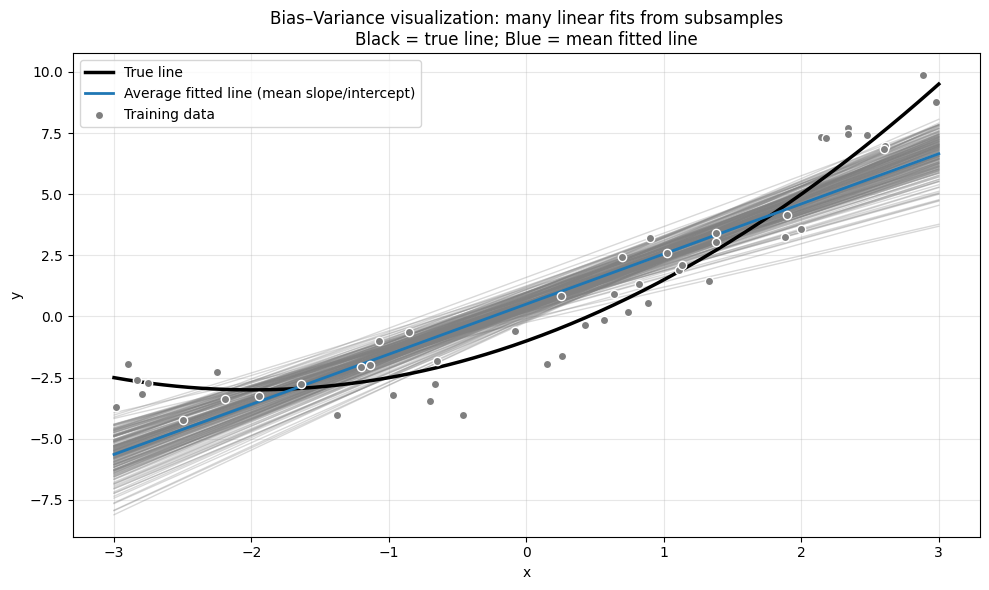

Fitted slope mean = 2.0486, slope std = 0.2334
Fitted intercept mean = 0.5072, intercept std = 0.3349


In [70]:
# Bias-variance visualization with linear fits (line + noise)
# - Generate training data from a true line y = a_true * x + b_true + noise
# - Repeatedly subsample the training data, fit OLS lines, and plot:
#     * many individual fitted lines (light, alpha)
#     * the average fitted line (mean slope & intercept)
#     * four "±1 sigma" lines built from mean ± std of intercept and slope
#     * the true underlying line
#
# User-adjustable parameters:
#  - n_points: number of points in each training sample
#  - n_subsamples: number of subsampled fits to draw (B)
#  - sample_fraction: fraction of the full dataset to fit each time (0<<=1)
#  - noise_std: standard deviation of additive noise in y
#  - random_state: for reproducibility
#
# Output: a single matplotlib figure with the requested elements and legend.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -------------------- User settings --------------------
n_points = 50            # points in the full training dataset
n_subsamples = 200       # number of subsampled fits (B)
sample_fraction = 0.4    # fraction of points used in each subsample
noise_std = 1.0          # noise standard deviation
random_state = 0
# -------------------------------------------------------

rng = np.random.default_rng(random_state)

# True underlying line parameters
a_true = 2.0   # slope
b_true = -1.0  # intercept
c_true = 0.5 # quadratic

# Generate a sufficiently dense x_grid for plotting lines
x_grid = np.linspace(-3, 3, 400)

# Create one full dataset (we will subsample from this)
X_full = rng.uniform(-3, 3, size=n_points)
y_full = a_true * X_full + b_true + c_true * X_full**2 + rng.normal(0, noise_std, size=n_points)

# Storage for fitted parameters
slopes = []
intercepts = []

# Subsampling and fitting
sample_size = max(2, int(np.round(sample_fraction * n_points)))  # at least 2 pts
for _ in range(n_subsamples):
    idx = rng.choice(n_points, size=sample_size, replace=False)
    X_sub = X_full[idx].reshape(-1, 1)
    y_sub = y_full[idx]
    model = LinearRegression()
    model.fit(X_sub, y_sub)
    slopes.append(model.coef_[0])
    intercepts.append(model.intercept_)

slopes = np.array(slopes)
intercepts = np.array(intercepts)

# Compute mean and std of fitted parameters
slope_mean = slopes.mean()
slope_std = slopes.std(ddof=1)
intercept_mean = intercepts.mean()
intercept_std = intercepts.std(ddof=1)

# Many individual lines (for visualizing variance)
plt.figure(figsize=(10, 6))
for m, c in zip(slopes, intercepts):
    plt.plot(x_grid, m * x_grid + c, color="gray", alpha=0.3, linewidth=1)

# True line
plt.plot(x_grid, a_true * x_grid + b_true + c_true * x_grid**2, color="black", linewidth=2.5, label="True line")

# Mean fitted line (average slope & intercept)
plt.plot(x_grid, slope_mean * x_grid + intercept_mean,
         color="tab:blue", linewidth=2, label="Average fitted line (mean slope/intercept)")

# Scatter the original full dataset for context
plt.scatter(X_full, y_full, color="tab:gray", edgecolor="white", zorder=5, label="Training data")

# Labels and legend
plt.xlabel("x")
plt.ylabel("y")
plt.title("Bias–Variance visualization: many linear fits from subsamples\n"
          "Black = true line; Blue = mean fitted line")
# Build legend: ensure one entry for the ±1σ group
handles, labels = plt.gca().get_legend_handles_labels()
# Remove duplicate "±1σ intercept/slope lines" labels if present
seen = set()
new_handles = []
new_labels = []
for h, l in zip(handles, labels):
    if l in seen:
        continue
    new_handles.append(h)
    new_labels.append(l)
    seen.add(l)
plt.legend(new_handles, new_labels, loc="best")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print numeric summary of parameter means and stds
print(f"Fitted slope mean = {slope_mean:.4f}, slope std = {slope_std:.4f}")
print(f"Fitted intercept mean = {intercept_mean:.4f}, intercept std = {intercept_std:.4f}")

# Linear fit to Quadratic Dataset - High Variance (because dataset is small)

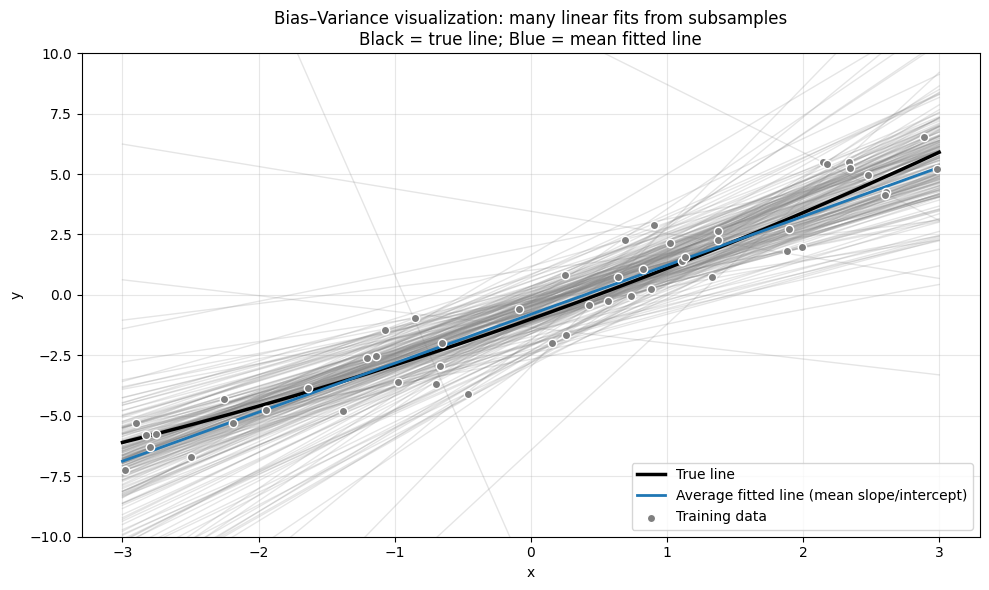

Fitted slope mean = 2.0251, slope std = 1.3261
Fitted intercept mean = -0.8015, intercept std = 1.5570


In [34]:
# Bias-variance visualization with linear fits (line + noise)
# - Generate training data from a true line y = a_true * x + b_true + noise
# - Repeatedly subsample the training data, fit OLS lines, and plot:
#     * many individual fitted lines (light, alpha)
#     * the average fitted line (mean slope & intercept)
#     * four "±1 sigma" lines built from mean ± std of intercept and slope
#     * the true underlying line
#
# User-adjustable parameters:
#  - n_points: number of points in each training sample
#  - n_subsamples: number of subsampled fits to draw (B)
#  - sample_fraction: fraction of the full dataset to fit each time (0<<=1)
#  - noise_std: standard deviation of additive noise in y
#  - random_state: for reproducibility
#
# Output: a single matplotlib figure with the requested elements and legend.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -------------------- User settings --------------------
n_points = 50            # points in the full training dataset
n_subsamples = 200       # number of subsampled fits (B)
sample_fraction = 0.06    # fraction of points used in each subsample
noise_std = 1.0          # noise standard deviation
random_state = 0
# -------------------------------------------------------

rng = np.random.default_rng(random_state)

# True underlying line parameters
a_true = 2.0   # slope
b_true = -1.0  # intercept
c_true = 0.1 # quadratic

# Generate a sufficiently dense x_grid for plotting lines
x_grid = np.linspace(-3, 3, 400)

# Create one full dataset (we will subsample from this)
X_full = rng.uniform(-3, 3, size=n_points)
y_full = a_true * X_full + b_true + c_true * X_full**2 + rng.normal(0, noise_std, size=n_points)

# Storage for fitted parameters
slopes = []
intercepts = []

# Subsampling and fitting
sample_size = max(2, int(np.round(sample_fraction * n_points)))  # at least 2 pts
for _ in range(n_subsamples):
    idx = rng.choice(n_points, size=sample_size, replace=False)
    X_sub = X_full[idx].reshape(-1, 1)
    y_sub = y_full[idx]
    model = LinearRegression()
    model.fit(X_sub, y_sub)
    slopes.append(model.coef_[0])
    intercepts.append(model.intercept_)

slopes = np.array(slopes)
intercepts = np.array(intercepts)

# Compute mean and std of fitted parameters
slope_mean = slopes.mean()
slope_std = slopes.std(ddof=1)
intercept_mean = intercepts.mean()
intercept_std = intercepts.std(ddof=1)

# Many individual lines (for visualizing variance)
plt.figure(figsize=(10, 6))
for m, c in zip(slopes, intercepts):
    plt.plot(x_grid, m * x_grid + c, color="gray", alpha=0.2, linewidth=1)

plt.ylim((-10, 10))

# True line
plt.plot(x_grid, a_true * x_grid + b_true + c_true * x_grid**2, color="black", linewidth=2.5, label="True line")

# Mean fitted line (average slope & intercept)
plt.plot(x_grid, slope_mean * x_grid + intercept_mean,
         color="tab:blue", linewidth=2, label="Average fitted line (mean slope/intercept)")

# Scatter the original full dataset for context
plt.scatter(X_full, y_full, color="tab:gray", edgecolor="white", zorder=5, label="Training data")

# Labels and legend
plt.xlabel("x")
plt.ylabel("y")
plt.title("Bias–Variance visualization: many linear fits from subsamples\n"
          "Black = true line; Blue = mean fitted line")
# Build legend: ensure one entry for the ±1σ group
handles, labels = plt.gca().get_legend_handles_labels()
# Remove duplicate "±1σ intercept/slope lines" labels if present
seen = set()
new_handles = []
new_labels = []
for h, l in zip(handles, labels):
    if l in seen:
        continue
    new_handles.append(h)
    new_labels.append(l)
    seen.add(l)
plt.legend(new_handles, new_labels, loc="best")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print numeric summary of parameter means and stds
print(f"Fitted slope mean = {slope_mean:.4f}, slope std = {slope_std:.4f}")
print(f"Fitted intercept mean = {intercept_mean:.4f}, intercept std = {intercept_std:.4f}")

# Polynomial fit to Quadratic dataset: High Variance (Because polynomial degree is high)

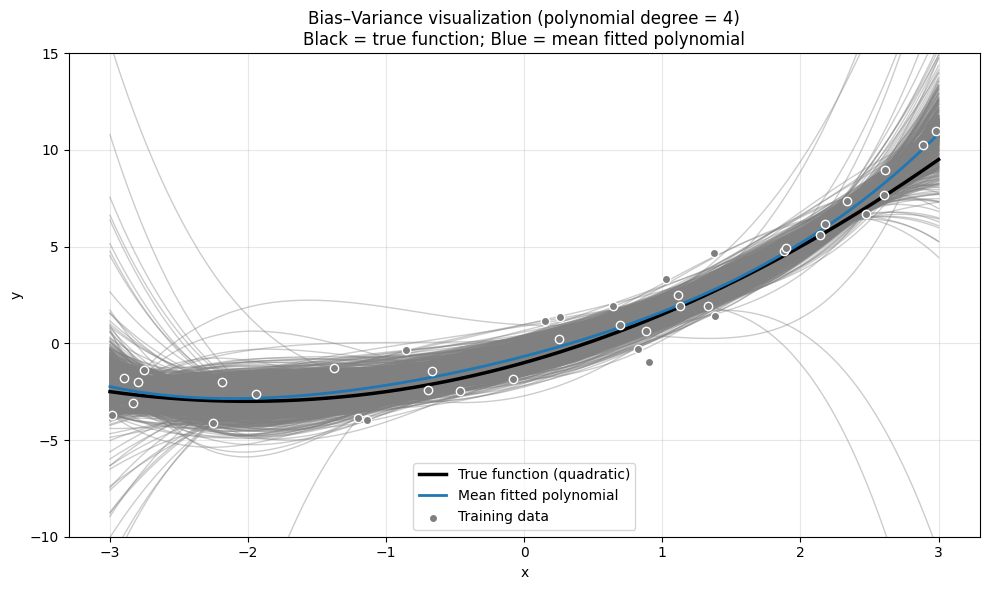

coeff for x^0: mean = -0.6719, std = 0.5055
coeff for x^1: mean = 1.8647, std = 0.4374
coeff for x^2: mean = 0.3813, std = 0.3497
coeff for x^3: mean = 0.0349, std = 0.0843
coeff for x^4: mean = 0.0190, std = 0.0458


In [42]:
# Polynomial bias-variance visualization with subsampled fits
# - Generate training data from a true quadratic function
#   y = a_true * x + b_true + c_true * x^2 + noise
# - Repeatedly subsample the training data, fit a polynomial of user-chosen degree,
#   and plot:
#     * many individual fitted polynomials (light, alpha)
#     * the average polynomial (mean coefficients)
#     * all 2^(degree+1) combinations of coefficients with ±1 sigma (to visualize parameter variance)
#     * the true underlying quadratic function
#
# User-adjustable parameters:
#  - n_points: full dataset size
#  - n_subsamples: number of subsampled fits (B)
#  - sample_fraction: fraction of the full dataset used per subsample
#  - noise_std: standard deviation of additive noise in y
#  - degree: degree of polynomial model to fit (non-negative integer)
#  - random_state: RNG seed
#
# Notes:
#  - For degree d there are d+1 coefficients (from x^0 to x^d); we compute mean and std for each coefficient.
#  - We plot all 2^(d+1) combinations of sign choices for ±1 sigma around each coefficient mean.
#  - For higher degree (d >= 6+) 2^(d+1) grows large; choose degree modestly (0..4 recommended).
#  - The true function here is quadratic; fitting higher-degree polynomials illustrates bias/variance tradeoffs.
#
# Output: matplotlib figure with the requested elements and a printed summary of coefficient stats.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from itertools import product

# -------------------- User settings --------------------
n_points = 40            # points in the full training dataset
n_subsamples = 1000       # number of subsampled fits (B)
sample_fraction = 0.4    # fraction of points used in each subsample (0 < f <= 1)
noise_std = 1.0          # noise standard deviation
degree = 4               # degree of polynomial model the user wants to fit (0,1,2,...)
random_state = 0
# -------------------------------------------------------

rng = np.random.default_rng(random_state)

# True underlying quadratic function parameters (we keep a quadratic truth regardless of fit degree)
a_true = 2.0    # linear coeff (x^1)
b_true = -1.0   # intercept (x^0)
c_true = 0.5    # quadratic coeff (x^2)

# Dense grid for plotting function curves
x_grid = np.linspace(-3, 3, 400)

# Create one full dataset (we will subsample from this)
X_full = rng.uniform(-3, 3, size=n_points)
y_full = a_true * X_full + b_true + c_true * X_full**2 + rng.normal(0, noise_std, size=n_points)

# Prepare polynomial transformer for the chosen degree
poly = PolynomialFeatures(degree, include_bias=True)  # includes column for x^0 (bias/intercept)

# Storage for coefficient vectors (length d+1)
coef_list = []

sample_size = max(2, int(np.round(sample_fraction * n_points)))  # at least 2 pts
for _ in range(n_subsamples):
    idx = rng.choice(n_points, size=sample_size, replace=False)
    X_sub = X_full[idx].reshape(-1, 1)
    y_sub = y_full[idx]
    X_sub_poly = poly.fit_transform(X_sub)  # shape (sample_size, degree+1)
    model = LinearRegression(fit_intercept=False)  # intercept included in polynomial features (x^0)
    model.fit(X_sub_poly, y_sub)
    # Store coefficients in order [coef_x^0, coef_x^1, ..., coef_x^d]
    coef_list.append(model.coef_.copy())

coef_array = np.vstack(coef_list)  # shape (B, d+1)

# Compute mean and std for each coefficient
coef_mean = coef_array.mean(axis=0)
coef_std = coef_array.std(axis=0, ddof=1)

# Plotting
plt.figure(figsize=(10, 6))

plt.ylim((-10, 15))

# Plot many individual fitted polynomials (light gray)
for coeffs in coef_array:
    # Evaluate polynomial on x_grid: use polyval-like evaluation
    # np.polyval expects highest-first; our coeffs are low-to-high, so reverse
    y_grid = np.polyval(coeffs[::-1], x_grid)
    plt.plot(x_grid, y_grid, color="gray", alpha=0.4, linewidth=1)

# Plot true quadratic function (solid black)
y_true_grid = a_true * x_grid + b_true + c_true * x_grid**2
plt.plot(x_grid, y_true_grid, color="black", linewidth=2.5, label="True function (quadratic)")

# Plot mean polynomial (mean coefficients) in blue
y_mean_grid = np.polyval(coef_mean[::-1], x_grid)
plt.plot(x_grid, y_mean_grid, color="tab:blue", linewidth=2, label="Mean fitted polynomial")

# Scatter the original full dataset for context
plt.scatter(X_full, y_full, color="tab:gray", edgecolor="white", zorder=5, label="Training data")

# Labels, title, legend
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Bias–Variance visualization (polynomial degree = {degree})\n"
          "Black = true function; Blue = mean fitted polynomial")
# Build legend ensuring a single entry for the ±1σ group
handles, labels = plt.gca().get_legend_handles_labels()
seen = set()
new_handles = []
new_labels = []
for h, l in zip(handles, labels):
    if l in seen:
        continue
    new_handles.append(h)
    new_labels.append(l)
    seen.add(l)
plt.legend(new_handles, new_labels, loc="best")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print numeric summary of coefficient means and stds
for i in range(d_plus_1):
    print(f"coeff for x^{i}: mean = {coef_mean[i]:.4f}, std = {coef_std[i]:.4f}")

# End of script

# Cross Validation

In [6]:
# Example: k-fold cross-validation for a DecisionTreeRegressor on the California housing dataset
# - Uses sklearn's cross_val_score to run k-fold CV and report mean and std of the chosen metric.
# - Dataset: fetch_california_housing (same dataset used earlier).
# - Model: DecisionTreeRegressor (user can change hyperparameters).
# - Metric: selectable (supports "neg_mean_squared_error", "neg_root_mean_squared_error", "r2", "neg_mean_absolute_error").
#
# Notes on sklearn scoring:
# - For loss metrics (MSE, RMSE, MAE) sklearn returns negative values by convention (so higher is better).
#   Example string keys: "neg_mean_squared_error", "neg_root_mean_squared_error", "neg_mean_absolute_error".
# - For utility metrics like R^2, the scorer returns positive values (higher is better): "r2".
#
# Change user_selectable variables below to try different settings.

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score, KFold
import sklearn

# --- User-selectable ---
tree_params = {
    "criterion": "squared_error",  # MSE split criterion
    "max_depth": 6,                # try None or other values
    "min_samples_leaf": 1,
    "random_state": 0
}
# Choose scoring: examples:
#   "neg_mean_squared_error"  (MSE, negative)
#   "neg_root_mean_squared_error" (RMSE, negative)
#   "neg_mean_absolute_error" (MAE, negative)
#   "r2"                      (R^2, positive)
scoring = "neg_root_mean_squared_error"

n_splits = 5  # number of folds in k-fold CV
shuffle_folds = True
cv_random_state = 0  # only used if shuffle_folds=True

# --- Load data ---
cal = fetch_california_housing()
X = pd.DataFrame(cal.data, columns=cal.feature_names)
y = pd.Series(cal.target, name="MedHouseVal")

# --- Cross-validation setup ---
kf = KFold(n_splits=n_splits, shuffle=shuffle_folds, random_state=cv_random_state)

# --- Model ---
dt = DecisionTreeRegressor(**tree_params)

# --- Run cross-validation ---
# cross_val_score returns an array of scores (one per fold). For negative-loss scorers, values are negative.
scores = cross_val_score(dt, X, y, scoring=scoring, cv=kf, n_jobs=-1)

# --- Interpretation / display ---
# If the scorer is a "neg_*" loss, we usually report the positive loss by negating the scores.
is_negative_loss = scoring.startswith("neg_")
if is_negative_loss:
    scores_to_report = -scores  # positive losses (e.g., RMSE)
    score_name = scoring.replace("neg_", "")
else:
    scores_to_report = scores
    score_name = scoring

print(f"sklearn version: {sklearn.__version__}")
print(f"Model params: {tree_params}")
print(f"Scoring used: {scoring}  (reporting {score_name})")
print(f"{n_splits}-fold CV scores (per fold):")
for i, s in enumerate(scores_to_report, 1):
    print(f" Fold {i}: {s:.6f}")
print(f"Mean {score_name}: {scores_to_report.mean():.6f}")
print(f"Std  {score_name}: {scores_to_report.std(ddof=1):.6f}")

# --- Additional: show fitted CV split details if you want to inspect one fold ---
# Example: train on fold 0's training set, fit, and show train/test RMSE for that split
# (useful for debugging or sanity checks)
train_index, test_index = list(kf.split(X))[0]
X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

dt_fold = DecisionTreeRegressor(**tree_params)
dt_fold.fit(X_train_fold, y_train_fold)
y_pred_train = dt_fold.predict(X_train_fold)
y_pred_test = dt_fold.predict(X_test_fold)

from sklearn.metrics import mean_squared_error
train_rmse = np.sqrt(mean_squared_error(y_train_fold, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test_fold, y_pred_test))

print("\nExample for fold 1 (train vs test on this fold):")
print(f" Train RMSE (fold 1): {train_rmse:.6f}")
print(f" Test  RMSE (fold 1): {test_rmse:.6f}")

sklearn version: 1.8.0
Model params: {'criterion': 'squared_error', 'max_depth': 6, 'min_samples_leaf': 1, 'random_state': 0}
Scoring used: neg_root_mean_squared_error  (reporting root_mean_squared_error)
5-fold CV scores (per fold):
 Fold 1: 0.705982
 Fold 2: 0.694313
 Fold 3: 0.701046
 Fold 4: 0.682445
 Fold 5: 0.654264
Mean root_mean_squared_error: 0.687610
Std  root_mean_squared_error: 0.020625

Example for fold 1 (train vs test on this fold):
 Train RMSE (fold 1): 0.657717
 Test  RMSE (fold 1): 0.705982


# Hyperparameter Tuning - Grid Search and Randomized Search

In [40]:
# Hyperparameter tuning for DecisionTreeRegressor on California housing dataset
# - Demonstrates (1) GridSearchCV and (2) RandomizedSearchCV
# - Uses k-fold cross-validation for both searches and reports best params and CV score.
# - Same data/model as earlier examples; user-selectable metric and search spaces are clearly marked.
#
# Notes:
# - sklearn's "neg_*" scoring returns negative losses so that higher is better for GridSearchCV.
# - Change the search spaces, n_iter, CV folds, and scoring as desired.

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold, train_test_split
from sklearn.metrics import mean_squared_error
import sklearn

# ------------------ User-selectable choices ------------------
# Scoring: choose one. For MSE/RMSE/MAE use the "neg_*" versions for sklearn searchers.
# Examples:
#   "neg_mean_squared_error", "neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"
scoring = "neg_root_mean_squared_error"

# Cross-validation folds
n_splits = 5
cv = KFold(n_splits=n_splits, shuffle=True, random_state=0)

# Grid search parameter grid (explicit list of values)
grid_param_grid = {
    "max_depth": [2, 4, 6, 8, None],
    "min_samples_leaf": [1, 2, 5, 10]
    # you can add "criterion": ["squared_error", "friedman_mse", ...] if desired
}

# Randomized search distributions (use lists or scipy distributions)
random_param_dist = {
    "max_depth": [None, 2, 3, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 5, 10]
}
n_iter = 20  # number of random parameter settings to try in RandomizedSearchCV

# Number of jobs for parallelism
n_jobs = -1

# Optional: hold out a small test set to evaluate final selected model
test_size = 0.25
random_state = 0
# --------------------------------------------------------------

# Load data and create train/test split
cal = fetch_california_housing()
X = pd.DataFrame(cal.data, columns=cal.feature_names)
y = pd.Series(cal.target, name="MedHouseVal")

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

# Base estimator (we'll pass fresh instances to the searchers)
base_estimator = DecisionTreeRegressor(random_state=0)

# ---------- 1) GridSearchCV ----------
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=0),
    param_grid=grid_param_grid,
    scoring=scoring,
    cv=cv,
    n_jobs=n_jobs,
    return_train_score=True,  # collects training scores too
    verbose=1
)

grid_search.fit(X_train_full, y_train_full)

print("=== GridSearchCV results ===")
print("sklearn version:", sklearn.__version__)
print("Search scoring:", scoring)
print("Best params (grid):", grid_search.best_params_)
# best_score_ is the CV score (according to scoring); if scoring is neg_*, it's negative.
best_score_grid = grid_search.best_score_
if scoring.startswith("neg_"):
    # convert to positive loss for interpretability
    print("Best CV (mean) (positive loss): {:.6f}".format(-best_score_grid))
else:
    print("Best CV (mean): {:.6f}".format(best_score_grid))

# Show top 5 parameter combinations by rank
cv_results = pd.DataFrame(grid_search.cv_results_)
top5 = cv_results.sort_values("rank_test_score").head(5)[[
    "rank_test_score", "params", "mean_test_score", "std_test_score", "mean_train_score", "std_train_score"
]]
# If scoring is negative loss, convert to positive for readability
if scoring.startswith("neg_"):
    top5["mean_test_score"] = -top5["mean_test_score"]
    top5["mean_train_score"] = -top5["mean_train_score"]
print("\nTop 5 grid results (converted to positive loss if applicable):")
print(top5.to_string(index=False))

# Evaluate the best grid model on held-out test set
best_grid_model = grid_search.best_estimator_
y_pred_test_grid = best_grid_model.predict(X_test)
test_rmse_grid = np.sqrt(mean_squared_error(y_test, y_pred_test_grid))
print("\nTest RMSE of best grid model:", test_rmse_grid)

# ---------- 2) RandomizedSearchCV ----------
random_search = RandomizedSearchCV(
    estimator=DecisionTreeRegressor(random_state=0),
    param_distributions=random_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    n_jobs=n_jobs,
    random_state=0,
    return_train_score=True,
    verbose=1
)

random_search.fit(X_train_full, y_train_full)

print("\n=== RandomizedSearchCV results ===")
print("Best params (random):", random_search.best_params_)
best_score_random = random_search.best_score_
if scoring.startswith("neg_"):
    print("Best CV (mean) (positive loss): {:.6f}".format(-best_score_random))
else:
    print("Best CV (mean): {:.6f}".format(best_score_random))

# Show top 5 random results
cv_results_r = pd.DataFrame(random_search.cv_results_)
top5r = cv_results_r.sort_values("rank_test_score").head(5)[[
    "rank_test_score", "params", "mean_test_score", "std_test_score", "mean_train_score", "std_train_score"
]]
if scoring.startswith("neg_"):
    top5r["mean_test_score"] = -top5r["mean_test_score"]
    top5r["mean_train_score"] = -top5r["mean_train_score"]
print("\nTop 5 random-search results (converted to positive loss if applicable):")
print(top5r.to_string(index=False))

# Evaluate the best random model on held-out test set
best_random_model = random_search.best_estimator_
y_pred_test_random = best_random_model.predict(X_test)
test_rmse_random = np.sqrt(mean_squared_error(y_test, y_pred_test_random))
print("\nTest RMSE of best random-search model:", test_rmse_random)

# ---------- Quick comparison ----------
print("\n=== Quick comparison on held-out test set (RMSE) ===")
print(f"Best GridSearch model test RMSE:   {test_rmse_grid:.6f}")
print(f"Best RandomSearch model test RMSE: {test_rmse_random:.6f}")
print("You can inspect grid_search.cv_results_ and random_search.cv_results_ for full details.")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
=== GridSearchCV results ===
sklearn version: 1.8.0
Search scoring: neg_root_mean_squared_error
Best params (grid): {'max_depth': None, 'min_samples_leaf': 10}
Best CV (mean) (positive loss): 0.622659

Top 5 grid results (converted to positive loss if applicable):
 rank_test_score                                      params  mean_test_score  std_test_score  mean_train_score  std_train_score
               1 {'max_depth': None, 'min_samples_leaf': 10}         0.622659        0.013007          0.445562         0.005897
               2    {'max_depth': 8, 'min_samples_leaf': 10}         0.644086        0.011837          0.574709         0.008171
               3     {'max_depth': 8, 'min_samples_leaf': 5}         0.646059        0.011881          0.569215         0.007887
               4  {'max_depth': None, 'min_samples_leaf': 5}         0.651874        0.007212          0.354414         0.002889
               5     {'max_d